# Sentiment scanner — demo notebook

All the logic lives in the `sent_trader` package now; this notebook only drives it and visualizes results.

Setup (once, from the repo root): `pip install -e ".[dev]"`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sent_trader import db, pipeline

Matplotlib is building the font cache; this may take a moment.


## Collect and score

One call scrapes current headlines, downloads the last month of daily bars, stores everything (raw titles, deduplicated), and scores any article the current model hasn't seen yet.

In [2]:
ticker = 'NVDA'

pipeline.scan(ticker)

{'ticker': 'NVDA',
 'articles_added': 100,
 'price_rows_added': 19,
 'articles_scored': 100}

## Inspect what's stored

Titles come back raw (no stemming), with the sentiment score and the model version that produced it.

In [3]:
sentiment = db.get_article_sentiment(ticker)
sentiment.tail(5)

,publish_date,title,score,label,model_version
95,2026-07-13T19:52:13+00:00,Citi Has a Stark Message for Nvidia Stock Fans...,0.0000,neutral,nltk-3.10.0
96,2026-07-13T20:04:29+00:00,NVIDIA (NVDA) Stock Target Price Set at $300 A...,0.0000,neutral,nltk-3.10.0
97,2026-07-13T20:30:55+00:00,Nvidia Stock NVDA Heads to $200 as Cloud Giant...,0.0772,positive,nltk-3.10.0
98,2026-07-13T21:24:06+00:00,NVIDIA Corp (NVDA) Stock Down 3.5% -- Now Unde...,0.0000,neutral,nltk-3.10.0
99,2026-07-13T21:45:04+00:00,Nvidia (NVDA) Registers a Bigger Fall Than the...,0.2023,positive,nltk-3.10.0


In [4]:
prices = db.get_stock_prices(ticker)
prices.tail(5)

,date,open,high,low,close,volume
14,2026-07-07T00:00:00,192.369995,198.410004,191.139999,196.929993,124154600
15,2026-07-08T00:00:00,195.179993,205.160004,195.059998,204.119995,147419100
16,2026-07-09T00:00:00,204.460007,204.589996,198.960007,202.779999,132037400
17,2026-07-10T00:00:00,202.000000,211.000000,201.919998,210.960007,148421000
18,2026-07-13T00:00:00,208.539993,210.570007,203.350006,203.529999,113202886


## Price vs daily average sentiment

VADER compound score interpretation:

| Compound score | Interpreted sentiment |
| --- | --- |
| `>= 0.05` | **Positive** |
| `<= -0.05` | **Negative** |
| between | **Neutral** |

In [5]:
sentiment_daily = (
    sentiment.groupby(pd.to_datetime(sentiment['publish_date'], utc=True, format='mixed').dt.date)['score']
    .mean()
    .reset_index()
    .rename(columns={'publish_date': 'date', 'score': 'avg_sentiment'})
)

prices['date'] = pd.to_datetime(prices['date'], utc=True, format='mixed').dt.date

merged = pd.merge(prices, sentiment_daily, on='date', how='left')
merged['avg_sentiment'] = merged['avg_sentiment'].fillna(0)

# z-score both series so they are comparable on one axis
merged['price_z'] = zscore(merged['close'])
merged['sent_z'] = zscore(merged['avg_sentiment'])
merged.head(10)

,date,open,high,low,close,volume,avg_sentiment,price_z,sent_z
0,2026-06-15,208.919998,212.710007,208.339996,212.449997,149936700,0.000000,1.789393,-0.193062
1,2026-06-16,211.179993,211.490005,207.289993,207.410004,125694100,0.000000,0.949638,-0.193062
2,2026-06-17,208.529999,209.210007,203.080002,204.649994,128363500,-0.361200,0.489769,-2.447193
3,2026-06-18,207.330002,211.389999,206.500000,210.690002,241272000,0.000000,1.496146,-0.193062
4,2026-06-22,211.440002,213.990005,207.720001,208.649994,122041400,0.000000,1.156243,-0.193062
5,2026-06-23,202.169998,203.770004,200.000000,200.039993,153496200,0.051325,-0.278341,0.127241
6,2026-06-24,200.119995,201.669998,196.580002,199.000000,151810700,0.213850,-0.451623,1.141506
7,2026-06-25,200.080002,200.800003,192.130005,195.740005,149550000,-0.064000,-0.994798,-0.592465
8,2026-06-26,193.119995,195.550003,191.220001,192.529999,179304100,0.076233,-1.529644,0.282685
9,2026-06-29,193.850006,196.179993,189.800003,194.970001,148835700,0.067433,-1.123095,0.227768


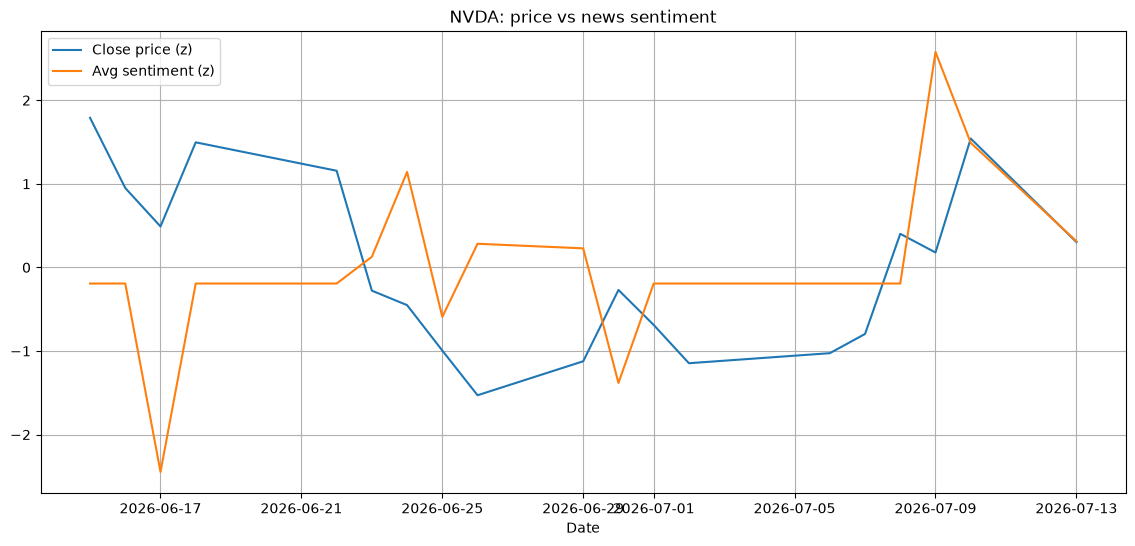

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(merged['date'], merged['price_z'], label='Close price (z)')
plt.plot(merged['date'], merged['sent_z'], label='Avg sentiment (z)')
plt.title(f'{ticker}: price vs news sentiment')
plt.xlabel('Date')
plt.legend()
plt.grid()
plt.show()

## Export

Same as `sent-trader export` on the command line.

In [ ]:
stock_df, article_df = db.export_dataframes()
stock_df.to_csv('stock_data.csv', index=False)
article_df.to_csv('article_data.csv', index=False)
len(stock_df), len(article_df)